# TESTE DE CONHECIMENTO

ALUNO: PAULO TAVARES PAJEU FILHO


DISCIPLINA: INTELIGÊNCIA ARTIFICIAL

# ETAPA 01: CARREGAR OS DADOS


In [40]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
from google.colab import files

files.upload()

Saving base_credito.csv to base_credito.csv


{'base_credito.csv': b'idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo\n47,11522.48,634,76.73,35229.74\n40,13157.86,589,90.83,44177.99\n38,7296.76,721,77.94,33868.3\n42,11193.87,710,94.09,52289.28\n43,12798.6,576,73.83,38663.54\n40,5842.28,708,67.78,26522.53\n40,3993.85,847,84.37,39544.67\n35,4933.07,630,100.0,26588.6\n56,6105.73,669,93.38,25099.7\n44,4430.53,637,93.11,24923.26\n39,2011.68,551,81.03,10665.71\n18,6359.47,535,80.74,22979.55\n59,5486.3,578,81.98,26413.52\n55,10264.44,678,88.04,37361.45\n54,10099.03,707,93.49,44976.85\n49,3497.86,615,78.19,21186.7\n38,7217.75,604,90.88,26354.66\n42,6331.55,641,84.36,29487.25\n42,1500.0,749,52.58,14241.71\n25,2363.8,482,83.13,6578.92\n32,5451.78,667,76.47,24742.24\n52,4001.55,784,73.09,26225.73\n56,5201.12,479,82.47,17287.76\n45,10094.52,700,69.24,43470.29\n34,4958.7,632,73.47,13701.35\n34,5705.99,649,95.62,20882.21\n40,6037.81,541,86.0,17094.26\n59,8851.76,662,83.46,29226.44\n39,2417.56,823,80.29,28257.83\n51,7558.99

In [41]:
df = pd.read_csv("base_credito.csv")

df

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


## Observação sobre a base de dados
A base de dados df possui um total de 50.000 linhas e 5 colunas.

# Etapa 02 – Conhecer os dados

In [42]:
print("Informações do DataFrame: ")
df.info()

print("\nEstatísticas Descritivas: ")
display(df.describe())

Informações do DataFrame: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB

Estatísticas Descritivas: 


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


## Explicação das Variáveis:
### Variáveis de Entrada (Features):


 **idade:** Idade do cliente. (Tipo: int64)

**renda_mensal:** Renda mensal do cliente. (Tipo: float64)

**score_credito:** Pontuação de crédito do cliente, indicando sua capacidade de pagamento. (Tipo: int64)

 **historico_pagamentos:** Histórico de pagamentos do cliente, representando a quantidade de pagamentos em dia (0 a 100, em porcentagem). (Tipo: float64)
### Variável alvo:


 **valor_emprestimo:** O valor do empréstimo que foi concedido, e é a variável que o modelo de regressão deverá prever. (Tipo: float64)

# Etapa 03 – Analisar os dados
## Análise da Relação entre Renda Mensal e Valor do Empréstimo

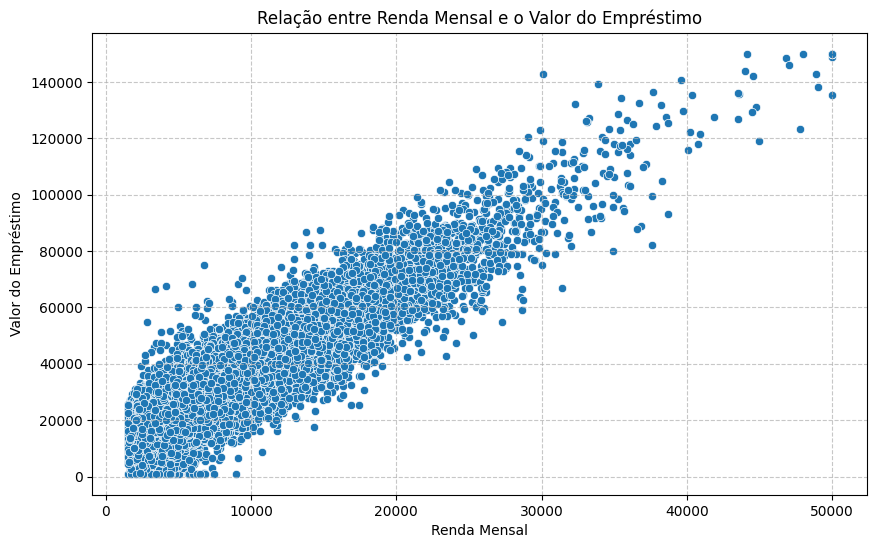

In [43]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda_mensal', y='valor_emprestimo', data=df)
plt.title('Relação entre Renda Mensal e o Valor do Empréstimo')
plt.xlabel('Renda Mensal')
plt.ylabel('Valor do Empréstimo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Comportamento Observado:
Olhando para o gráfico, fica bem claro que a renda mensal e o valor do empréstimo andam juntos: à medida que os ganhos do cliente aumentam, o valor liberado ou solicitado também tende a subir. Outro detalhe é que, nas faixas de renda mais altas, os pontos do gráfico se espalham mais. Mostrando que, entre os clientes que ganham mais, existe uma variação bem maior nos valores de empréstimo do que entre aqueles com rendas menores.

# Etapa 04 – Preparar os dados
Agora, irei dividir a base de dados em duas partes:

Treino (70%): Onde o modelo "estuda". Ele vai usar esses dados para aprender os padrões e entender como as variáveis se relacionam.

Teste (30%): É o teste de fogo. Essa parte serve para avaliar o desempenho do modelo em dados inéditos, garantindo que ele realmente aprendeu e consegue fazer boas estimativas na prática.

Também fixei o random_state para garantir que a divisão seja sempre a mesma, permitindo replicar e comparar os resultados depois.

In [44]:
from sklearn.model_selection import train_test_split
X = df.drop('valor_emprestimo', axis=1)
y = df['valor_emprestimo']

# Dividindo os dados: 70% para treino do modelo e 30% para teste final
# O random_state garante que os mesmos dados sejam selecionados ao rodar novamente
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Shape do conjunto de treinamento (features): {X_train.shape}')
print(f'Shape do conjunto de teste (features): {X_test.shape}')
print(f'Shape do conjunto de treinamento (target): {y_train.shape}')
print(f'Shape do conjunto de teste (target): {y_test.shape}')


Shape do conjunto de treinamento (features): (35000, 4)
Shape do conjunto de teste (features): (15000, 4)
Shape do conjunto de treinamento (target): (35000,)
Shape do conjunto de teste (target): (15000,)


# Etapa 05 – Treinar o modelo
## Construção e Treinamento do Modelo de Regressão Linear
Para estimar os valores, vamos usar a **Regressão Linear**, um algoritmo bem intuitivo para prever valores contínuos. A ideia dele é encontrar a linha (ou relação matemática) que melhor se ajusta aos nossos dados.

### O processo é dividido em três passos simples:
**Criar o modelo:** Criamos a instância do LinearRegression.

**Treinar:** Apresentamos os dados de treino (X_train e y_train) para que o modelo aprenda os padrões.

**Prever:** Aplicamos o modelo nos dados de teste (X_test) para gerar as estimativas e conferir como ele se sai com dados novos.

In [45]:
from sklearn.linear_model import LinearRegression

try:
    # 1. Criar o modelo:
    model = LinearRegression()

    # 2. Treinar o modelo:
    model.fit(X_train, y_train)

    print("Modelo de Regressão Linear ajustado perfeitamente!")

    # 3. Gerar as previsões:
    y_pred = model.predict(X_test)

    print("Previsões do conjunto de teste concluídas.")

except Exception as erro:
    print("Houve uma falha durante o processo de treino ou inferência.")
    print("Especificação do erro:", erro)

Modelo de Regressão Linear ajustado perfeitamente!
Previsões do conjunto de teste concluídas.


# Etapa 06 – Avaliar o Modelo
Finalizadas as etapas de treino e predição, passamos para a validação do modelo. A ideia é quantificar a margem de erro e a assertividade da Regressão Linear utilizando o conjunto de métricas a seguir:

**Erro Absoluto Médio (MAE):** Mostra, em média, quanto a estimativa do modelo errou em relação ao valor real (para mais ou para menos). Por ser medido na mesma unidade do valor do empréstimo (em reais), é muito simples e direto de interpretar.

**Erro Quadrático Médio (MSE):** Mede a média dos erros elevados ao quadrado. A grande diferença aqui é que ele pesa muito mais os erros grandes. Se o modelo cometer um desvio muito fora da curva, o MSE vai "cobrar caro", sendo ideal para identificar se existem discrepâncias graves nas previsões.

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculando a margem de erro média em reais
mae = mean_absolute_error(y_test, y_pred)
print(f'Erro Absoluto Médio (MAE): R$ {mae:.2f}')

# Calculando a penalização dos maiores desvios (ao quadrado)
mse = mean_squared_error(y_test, y_pred)
print(f'Erro Quadrático Médio (MSE): {mse:.2f}')

Erro Absoluto Médio (MAE): R$ 3001.04
Erro Quadrático Médio (MSE): 16045712.28


## Interpretação dos Resultados:

MAE (Erro Absoluto Médio): O resultado de R$ 3.001,04 indica que, em média, o nosso modelo erra cerca de 3 mil reais ao estimar o valor de um empréstimo (seja para mais ou para menos). Em termos práticos de negócio, quanto menor esse valor, mais precisas são as concessões.

MSE (Erro Quadrático Médio): O valor de 16.045.712,28 mede o erro ao quadrado. Por elevar os desvios ao quadrado, ele dá um peso muito maior para erros pontuais mais graves, ajudando a identificar se o modelo cometeu grandes deslizes em casos específicos.

# Etapa 07 – Comparar valores reais e previstos

In [25]:
# Criação do DataFrame para fazer a comparação de valores reais (y_test) e os valores previstos (y_pred)
comparison_df = pd.DataFrame({'Valor Real': y_test, 'Valor Previsto': y_pred})

print("Valores Reais e Previstos (15 primeiros resultados):")
display(comparison_df.head(15))

Valores Reais e Previstos (15 primeiros resultados):


,Valor Real,Valor Previsto
33553,22268.46,14795.304141
9427,27457.59,29514.265230
199,25451.04,25806.438027
12447,23890.67,21081.147964
39489,27754.95,27899.326404
42724,12544.92,14506.091353
10822,28759.01,27409.433130
49498,46454.49,41005.125572
4144,43199.01,36523.077074
36958,34051.39,35761.144897


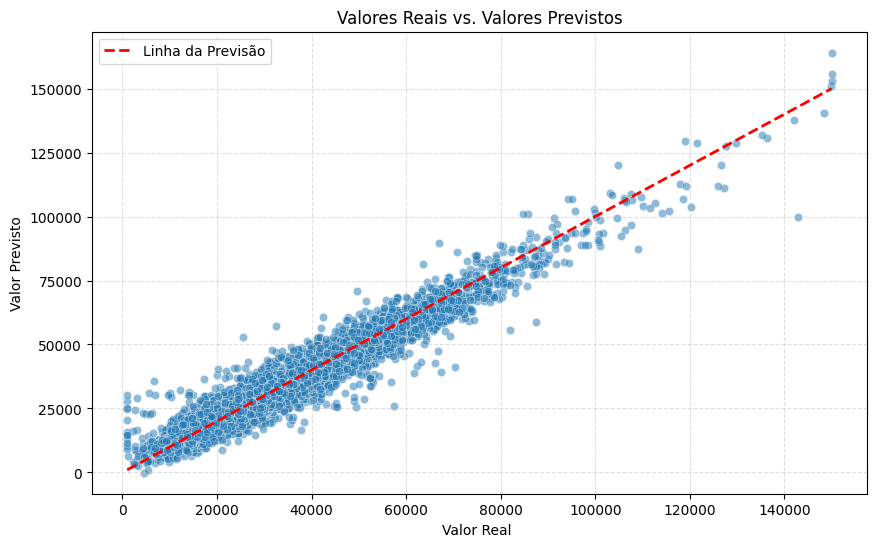

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Valor Real', y='Valor Previsto', data=comparison_df, alpha=0.5)
plt.title('Valores Reais vs. Valores Previstos')
plt.xlabel('Valor Real ')
plt.ylabel('Valor Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Linha da Previsão')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## O que o gráfico e a tabela nos mostram:

**Visão Amostral (Tabela):** A tabela nos dá um panorama prático da precisão do modelo. Em alguns clientes, o valor estimado foi quase idêntico ao real, enquanto em outros houve um desvio um pouco maior.

**Comportamento Geral (Gráfico):** O gráfico de dispersão ajuda a enxergar o todo: a linha tracejada em vermelho marca onde estaria a "previsão exata". Como os pontos azuis acompanham o trajeto da linha ao longo de toda a faixa de valores, confirmamos que o modelo consegue prever bem tanto empréstimos menores quanto maiores. As pequenas oscilações ao redor da linha explicam de forma visual os desvios calculados pelo MAE e MSE.

# Etapa 08 – Fazer uma previsão

In [39]:
novo_cliente_data = {
    'idade': [29],
    'renda_mensal': [6200.00],
    'score_credito': [680],
    'historico_pagamentos': [89.0]  #(em porcentagem)
}

novo_cliente_df = pd.DataFrame(novo_cliente_data)

print("Características do Novo Cliente:")
display(novo_cliente_df)

valor_emprestimo_previsto = model.predict(novo_cliente_df)

print(f"\nO valor de empréstimo previsto para este novo cliente é: R$ {valor_emprestimo_previsto[0]:.2f}")

Características do Novo Cliente:


,idade,renda_mensal,score_credito,historico_pagamentos
0,29,6200.0,680,89.0



O valor de empréstimo previsto para este novo cliente é: R$ 29871.15


## Interpretação do Resultad
### Teste com Novo Cliente:

**Dados de Entrada:** 29 anos, renda de R$ 6.200,00, score de 680 e 89,0% de pagamentos em dia.

**Valor Estimado pelo Modelo:** R$ 29.871,15

Essa estimativa serve como um ponto de partida para acelerar a triagem de crédito da empresa. Como o modelo aprendeu a partir de dados históricos, a concessão definitiva e o limite final liberado ainda dependem do cumprimento das diretrizes de risco e regras internas da fintech.

# ETAPA 09 - CONCLUSÃO
O modelo de Regressão Linear apresentou um desempenho bastante satisfatório para prever os valores de empréstimo. Com um erro absoluto médio (MAE) de R$ 3.001,04 e um coeficiente de determinação ($R^2$) superior a 92%, a ferramenta consegue capturar muito bem a tendência geral do negócio. O gráfico de dispersão reforça esse bom alinhamento entre as estimativas e os valores reais.

**Principais Limitações:** Linearidade: Por ser uma Regressão Linear, o algoritmo assume relações estritamente diretas entre as variáveis. Caso existam padrões não lineares ou interações mais complexas entre os dados dos clientes, o modelo não conseguirá capturá-los perfeitamente.


**Sensibilidade a Grandes Desvios:** O valor do MSE (16.045.712,28) evidencia a presença de erros pontuais maiores. Por elevar as diferenças ao quadrado, o MSE deixa claro que em alguns perfis específicos a previsão ficou mais distante do real.

**Dependência do Histórico:** As previsões refletem estritamente o comportamento do banco de dados de treino. Se o perfil de novos clientes mudar drasticamente (mudanças econômicas, novos comportamentos de consumo), a precisão do modelo pode ser impactada.